In [1]:
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

# load your .env file
load_dotenv("../backend/.env")   # adjust path if needed

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:5432/{os.getenv('DB_NAME')}"
)

In [2]:
import pandas as pd
df_funnel = pd.read_sql("""
    with funnel as(
	select count(distinct case when event_type='signup_completed' then user_id end) as signup,
	count(distinct case when event_type='email_verified' then user_id end) as email,
	count(distinct case when event_type='onboarding_completed' then user_id end) as onboarding,
	count(distinct case when event_type='risk_quiz_completed' then user_id end) as risk_quiz,
	count(distinct case when event_type='kyc_completed' then user_id end) as kyc,
	count(distinct case when event_type='deposit_completed' then user_id end) as deposit,
	count(distinct case when event_type='portfolio_created' then user_id end) as portfolio
	from events
)
select 
	250000 as total_users,
	signup, round((signup*100/250000),1) as signup_pct,
	email, round((email*100/signup),1) as email_of_signup,
	onboarding,    ROUND(onboarding * 100.0 / email, 1)AS onboard_of_email,
    risk_quiz,     ROUND(risk_quiz * 100.0 / onboarding,1) AS quiz_of_onboard,
    kyc,           ROUND(kyc * 100.0 / risk_quiz, 1)   AS kyc_of_quiz,
    deposit,       ROUND(deposit * 100.0 / kyc, 1)     AS deposit_of_kyc,
    portfolio,     ROUND(portfolio * 100.0 / deposit, 1) AS portfolio_of_deposit
from funnel;
""", engine)

In [3]:
df_funnel

,total_users,signup,signup_pct,email,email_of_signup,onboarding,onboard_of_email,risk_quiz,quiz_of_onboard,kyc,kyc_of_quiz,deposit,deposit_of_kyc,portfolio,portfolio_of_deposit
0,250000,175277,70.0,148947,84.0,133994,90.0,55447,41.4,49426,89.1,31926,64.6,30388,95.2


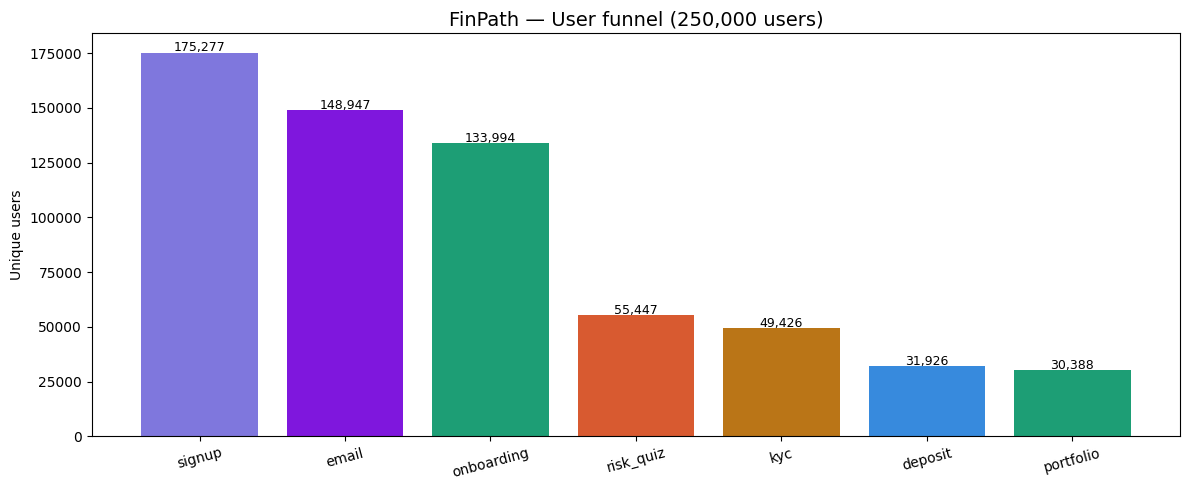

In [4]:
import matplotlib.pyplot as plt
stages = ['signup', 'email', 'onboarding', 'risk_quiz', 'kyc', 'deposit', 'portfolio']
values = [df_funnel[s].values[0] for s in stages]

plt.figure(figsize=(12, 5))
bars = plt.bar(stages, values, color=['#7F77DD','#7F17DD','#1D9E75',
                                       '#D85A30','#BA7517','#378ADD','#1D9E75'])
plt.title('FinPath — User funnel (250,000 users)', fontsize=14)
plt.ylabel('Unique users')
plt.xticks(rotation=15)

# add value labels on bars
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{int(val):,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('funnel_chart.png', dpi=150)
plt.show()

In [5]:
dropoff_query = """
WITH stage_events AS (
    SELECT
        user_id,
        MAX(CASE WHEN event_type = 'signup_completed'     THEN 1 ELSE 0 END) AS did_signup,
        MAX(CASE WHEN event_type = 'email_verified'       THEN 1 ELSE 0 END) AS did_email,
        MAX(CASE WHEN event_type = 'onboarding_completed' THEN 1 ELSE 0 END) AS did_onboard,
        MAX(CASE WHEN event_type = 'risk_quiz_completed'  THEN 1 ELSE 0 END) AS did_quiz,
        MAX(CASE WHEN event_type = 'kyc_completed'        THEN 1 ELSE 0 END) AS did_kyc,
        MAX(CASE WHEN event_type = 'deposit_completed'    THEN 1 ELSE 0 END) AS did_deposit,
        MAX(CASE WHEN event_type = 'portfolio_created'    THEN 1 ELSE 0 END) AS did_portfolio
    FROM events
    GROUP BY user_id
),
totals AS (
    SELECT
        SUM(did_signup)   AS s1,
        SUM(did_email)    AS s2,
        SUM(did_onboard)  AS s3,
        SUM(did_quiz)     AS s4,
        SUM(did_kyc)      AS s5,
        SUM(did_deposit)  AS s6,
        SUM(did_portfolio)AS s7
    FROM stage_events
)
SELECT stage, started, finished,
       started - finished AS dropped_off,
       ROUND((1 - finished::numeric / started) * 100, 1) AS dropoff_pct
FROM (
    SELECT 'signup → email'      AS stage, s1 AS started, s2 AS finished FROM totals
    UNION ALL
    SELECT 'email → onboarding',            s2, s3 FROM totals
    UNION ALL
    SELECT 'onboarding → quiz',             s3, s4 FROM totals
    UNION ALL
    SELECT 'quiz → kyc',                    s4, s5 FROM totals
    UNION ALL
    SELECT 'kyc → deposit',                 s5, s6 FROM totals
    UNION ALL
    SELECT 'deposit → portfolio',           s6, s7 FROM totals
) t
ORDER BY dropoff_pct DESC
"""


In [6]:
df_dropoff=pd.read_sql(dropoff_query,engine)
df_dropoff

,stage,started,finished,dropped_off,dropoff_pct
0,onboarding → quiz,133994,55447,78547,58.6
1,kyc → deposit,49426,31926,17500,35.4
2,signup → email,175277,148947,26330,15.0
3,quiz → kyc,55447,49426,6021,10.9
4,email → onboarding,148947,133994,14953,10.0
5,deposit → portfolio,31926,30388,1538,4.8


In [7]:
time_query = """
WITH user_timestamps AS (
    SELECT
        user_id,
        MIN(CASE WHEN event_type = 'signup_completed'     THEN timestamp END) AS t_signup,
        MIN(CASE WHEN event_type = 'email_verified'       THEN timestamp END) AS t_email,
        MIN(CASE WHEN event_type = 'onboarding_completed' THEN timestamp END) AS t_onboard,
        MIN(CASE WHEN event_type = 'risk_quiz_completed'  THEN timestamp END) AS t_quiz,
        MIN(CASE WHEN event_type = 'kyc_completed'        THEN timestamp END) AS t_kyc,
        MIN(CASE WHEN event_type = 'deposit_completed'    THEN timestamp END) AS t_deposit,
        MIN(CASE WHEN event_type = 'portfolio_created'    THEN timestamp END) AS t_portfolio
    FROM events
    GROUP BY user_id
),
diffs AS (
    SELECT
        EXTRACT(EPOCH FROM (t_email     - t_signup))   / 3600 AS hrs_to_email,
        EXTRACT(EPOCH FROM (t_onboard   - t_email))    / 3600 AS hrs_to_onboard,
        EXTRACT(EPOCH FROM (t_quiz      - t_onboard))  / 3600 AS hrs_to_quiz,
        EXTRACT(EPOCH FROM (t_kyc       - t_quiz))     / 3600 AS hrs_to_kyc,
        EXTRACT(EPOCH FROM (t_deposit   - t_kyc))      / 3600 AS hrs_to_deposit,
        EXTRACT(EPOCH FROM (t_portfolio - t_deposit))  / 3600 AS hrs_to_portfolio
    FROM user_timestamps
    WHERE t_signup IS NOT NULL
)
SELECT
    ROUND(AVG(hrs_to_email)::numeric,     1) AS avg_signup_to_email,
    ROUND(AVG(hrs_to_onboard)::numeric,   1) AS avg_email_to_onboard,
    ROUND(AVG(hrs_to_quiz)::numeric,      1) AS avg_onboard_to_quiz,
    ROUND(AVG(hrs_to_kyc)::numeric,       1) AS avg_quiz_to_kyc,
    ROUND(AVG(hrs_to_deposit)::numeric,   1) AS avg_kyc_to_deposit,
    ROUND(AVG(hrs_to_portfolio)::numeric, 1) AS avg_deposit_to_portfolio,

    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY hrs_to_email)::numeric,     1) AS med_signup_to_email,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY hrs_to_onboard)::numeric,   1) AS med_email_to_onboard,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY hrs_to_quiz)::numeric,      1) AS med_onboard_to_quiz,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY hrs_to_kyc)::numeric,       1) AS med_quiz_to_kyc,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY hrs_to_deposit)::numeric,   1) AS med_kyc_to_deposit,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY hrs_to_portfolio)::numeric, 1) AS med_deposit_to_portfolio
FROM diffs
"""

df_time = pd.read_sql(time_query, engine)
df_time

,avg_signup_to_email,avg_email_to_onboard,avg_onboard_to_quiz,avg_quiz_to_kyc,avg_kyc_to_deposit,avg_deposit_to_portfolio,med_signup_to_email,med_email_to_onboard,med_onboard_to_quiz,med_quiz_to_kyc,med_kyc_to_deposit,med_deposit_to_portfolio
0,36.5,1.1,48.1,76.2,84.6,0.1,36.4,1.1,48.0,74.7,84.8,0.1


In [8]:
avg_cols = [c for c in df_time.columns if c.startswith('avg')]
med_cols = [c for c in df_time.columns if c.startswith('med')]

df_display = pd.DataFrame({
    'stage':   ['signup→email', 'email→onboard', 'onboard→quiz',
                 'quiz→kyc', 'kyc→deposit', 'deposit→portfolio'],
    'avg_hrs': df_time[avg_cols].values[0],
    'med_hrs': df_time[med_cols].values[0]
})

df_display

,stage,avg_hrs,med_hrs
0,signup→email,36.5,36.4
1,email→onboard,1.1,1.1
2,onboard→quiz,48.1,48.0
3,quiz→kyc,76.2,74.7
4,kyc→deposit,84.6,84.8
5,deposit→portfolio,0.1,0.1


### Key insight — time metrics
- Users who verify email do it within ~1.5 days of signup
- The biggest time gap is **kyc → deposit** at ~9 days
  This is the most important re-engagement window —
  a nudge notification here could significantly improve deposit conversion
- deposit → portfolio happens almost instantly (same session)
  meaning users who deposit are highly motivated to invest immediately

In [9]:
cohort_query = """
WITH user_cohorts AS (
    -- Step 1: assign each user their signup week
    SELECT
        user_id,
        DATE_TRUNC('week', signup_at) AS cohort_week
    FROM users
),
user_activity AS (
    -- Step 2: find every week each user was active
    SELECT
        user_id,
        DATE_TRUNC('week', timestamp) AS active_week
    FROM events
    GROUP BY user_id, DATE_TRUNC('week', timestamp)
),
cohort_activity AS (
    -- Step 3: calculate weeks since signup for each activity
    SELECT
        c.cohort_week,
        EXTRACT(EPOCH FROM (a.active_week - c.cohort_week))
            / (7 * 86400)              AS weeks_since_signup,
        a.user_id
    FROM user_cohorts c
    JOIN user_activity a ON c.user_id = a.user_id
),
cohort_sizes AS (
    -- how many users in each cohort
    SELECT cohort_week, COUNT(*) AS cohort_size
    FROM user_cohorts
    GROUP BY cohort_week
)
SELECT
    TO_CHAR(ca.cohort_week, 'YYYY-MM-DD')   AS cohort_week,
    cs.cohort_size,
    SUM(CASE WHEN weeks_since_signup = 0  THEN 1 ELSE 0 END) AS week_0,
    SUM(CASE WHEN weeks_since_signup = 1  THEN 1 ELSE 0 END) AS week_1,
    SUM(CASE WHEN weeks_since_signup = 2  THEN 1 ELSE 0 END) AS week_2,
    SUM(CASE WHEN weeks_since_signup = 4  THEN 1 ELSE 0 END) AS week_4,
    SUM(CASE WHEN weeks_since_signup = 8  THEN 1 ELSE 0 END) AS week_8,
    SUM(CASE WHEN weeks_since_signup = 12 THEN 1 ELSE 0 END) AS week_12,

    -- as percentages of cohort size
    ROUND(SUM(CASE WHEN weeks_since_signup = 0  THEN 1 ELSE 0 END) * 100.0 / cs.cohort_size, 1) AS pct_w0,
    ROUND(SUM(CASE WHEN weeks_since_signup = 1  THEN 1 ELSE 0 END) * 100.0 / cs.cohort_size, 1) AS pct_w1,
    ROUND(SUM(CASE WHEN weeks_since_signup = 2  THEN 1 ELSE 0 END) * 100.0 / cs.cohort_size, 1) AS pct_w2,
    ROUND(SUM(CASE WHEN weeks_since_signup = 4  THEN 1 ELSE 0 END) * 100.0 / cs.cohort_size, 1) AS pct_w4,
    ROUND(SUM(CASE WHEN weeks_since_signup = 8  THEN 1 ELSE 0 END) * 100.0 / cs.cohort_size, 1) AS pct_w8,
    ROUND(SUM(CASE WHEN weeks_since_signup = 12 THEN 1 ELSE 0 END) * 100.0 / cs.cohort_size, 1) AS pct_w12

FROM cohort_activity ca
JOIN cohort_sizes cs ON ca.cohort_week = cs.cohort_week
GROUP BY ca.cohort_week, cs.cohort_size
ORDER BY ca.cohort_week
LIMIT 20
"""

df_cohort = pd.read_sql(cohort_query, engine)

# show only the percentage columns — cleaner to read
pct_cols = ['cohort_week', 'cohort_size', 'pct_w0', 'pct_w1', 
            'pct_w2', 'pct_w4', 'pct_w8', 'pct_w12']
df_cohort[pct_cols]

,cohort_week,cohort_size,pct_w0,pct_w1,pct_w2,pct_w4,pct_w8,pct_w12
0,2024-01-01,4794,100.0,38.8,13.4,2.1,2.1,1.5
1,2024-01-08,4733,100.0,37.8,13.2,2.4,2.2,1.6
2,2024-01-15,4578,100.0,37.5,13.1,2.3,2.0,1.7
3,2024-01-22,4828,100.0,37.7,12.5,1.9,1.7,1.7
4,2024-01-29,4835,100.0,37.8,12.7,2.0,1.7,1.4
5,2024-02-05,4849,100.0,38.7,13.2,2.1,1.9,1.6
6,2024-02-12,4842,100.0,38.4,13.2,2.0,2.1,1.6
7,2024-02-19,4817,100.0,38.6,14.4,2.6,2.2,1.5
8,2024-02-26,4753,100.0,39.3,13.2,2.5,2.3,1.6
9,2024-03-04,4863,100.0,38.1,13.2,2.0,2.0,1.6


## Cohort Retention Analysis

Analyzed weekly retention across 250,000 simulated users throughout 2024.

### Key findings

- **Week 0 → Week 1 drop is the biggest cliff (62% disengage)**
  Most users who don't complete KYC and deposit in their first week
  never return. This is the single biggest retention problem.

- **Week 1 → Week 2 drops another 25%**
  Users still in the KYC/deposit funnel either complete it or abandon
  permanently within the first two weeks.

- **Week 4+ stabilizes at ~2% long-term**
  These are fully activated users — completed KYC, deposited, created
  portfolio. Small in number but highest lifetime value.

- **Retention is consistent across all 2024 cohorts**
  No seasonal variation. Every month's cohort behaves identically —
  expected from simulation but in production would mean no product
  changes impacted retention during the year.

### Business recommendation
The entire retention strategy should focus on Week 0 → Week 1.
Specifically: reduce KYC friction, send email nudges at day 3 and day 6
for users who started but didn't complete KYC, and offer a guided
first-deposit experience immediately after KYC completion.

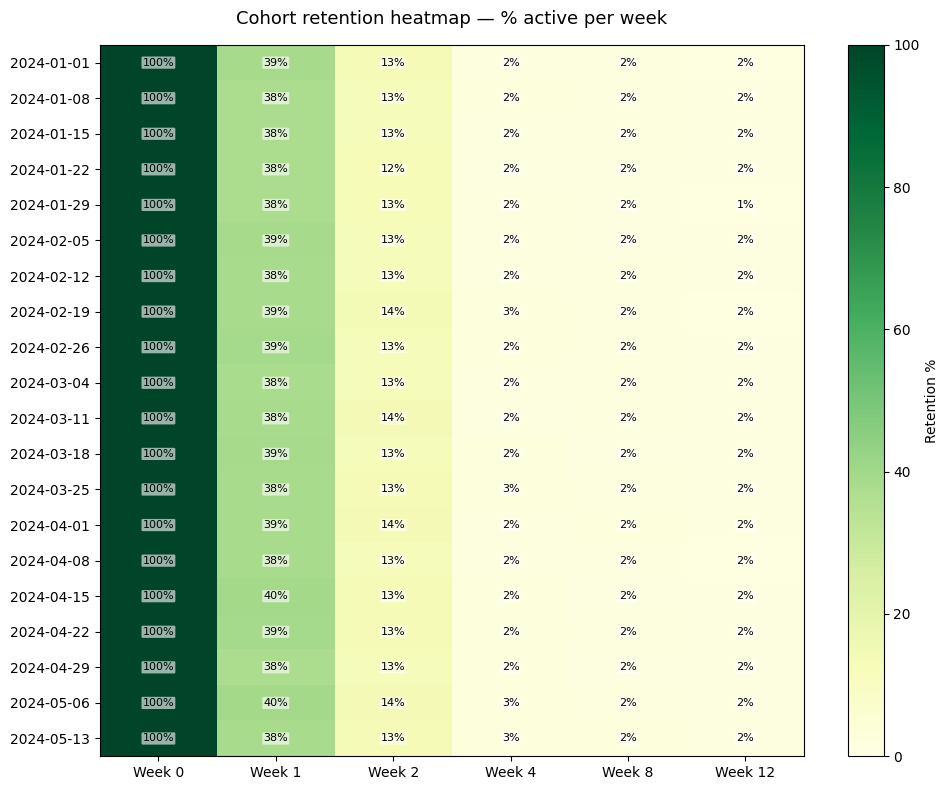

In [10]:
import matplotlib.pyplot as plt
import numpy as np

pct_cols_only = ['pct_w0','pct_w1','pct_w2','pct_w4','pct_w8','pct_w12']
matrix = df_cohort[pct_cols_only].values.astype(float)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(matrix, cmap='YlGn', aspect='auto', vmin=0, vmax=100)

ax.set_xticks(range(6))
ax.set_xticklabels(['Week 0', 'Week 1', 'Week 2', 'Week 4', 'Week 8', 'Week 12'])
ax.set_yticks(range(len(df_cohort)))
ax.set_yticklabels(df_cohort['cohort_week'])
ax.set_title('Cohort retention heatmap — % active per week', fontsize=13, pad=15)

for i in range(len(df_cohort)):
    for j in range(6):
        val = matrix[i, j]
        ax.text(j, i, f'{val:.0f}%',
                ha='center', va='center', fontsize=8,
                color='black',
                bbox=dict(boxstyle='round,pad=0.1',
                         facecolor='white',
                         alpha=0.6,
                         edgecolor='none'))

plt.colorbar(im, ax=ax, label='Retention %')
plt.tight_layout()
plt.savefig('cohort_heatmap.png', dpi=150)
plt.show()

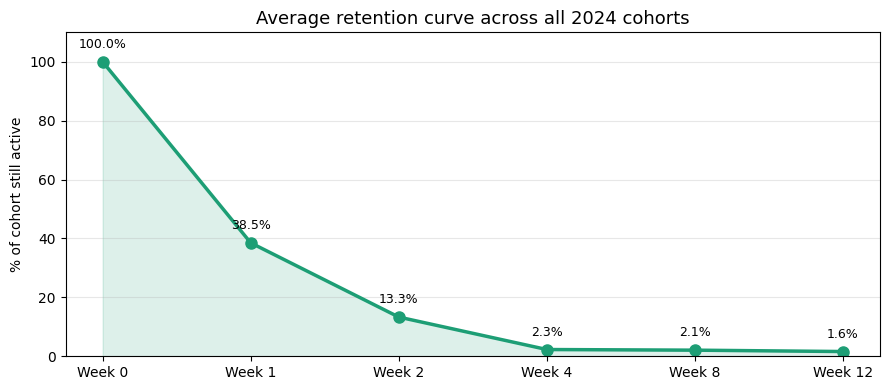

In [11]:
avg_retention = df_cohort[pct_cols_only].mean()
weeks = ['Week 0', 'Week 1', 'Week 2', 'Week 4', 'Week 8', 'Week 12']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(weeks, avg_retention.values, marker='o', linewidth=2.5,
        color='#1D9E75', markersize=8)
ax.fill_between(weeks, avg_retention.values, alpha=0.15, color='#1D9E75')

for i, val in enumerate(avg_retention.values):
    ax.annotate(f'{val:.1f}%', (i, val),
                textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=9)

ax.set_title('Average retention curve across all 2024 cohorts', fontsize=13)
ax.set_ylabel('% of cohort still active')
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cohort_retention_curve.png', dpi=150)
plt.show()

In [12]:
risk_behavior_query = """
WITH user_stats AS (
    SELECT
        u.user_id,
        u.risk_profile,
        u.country,
        u.device_type,

        -- deposit behavior
        COUNT(CASE WHEN e.event_type = 'deposit_completed'    THEN 1 END) AS total_deposits,
        AVG(CASE WHEN e.event_type = 'deposit_completed'
                 THEN (e.properties->>'amount')::numeric END)             AS avg_deposit_amount,
        SUM(CASE WHEN e.event_type = 'deposit_completed'
                 THEN (e.properties->>'amount')::numeric END)             AS total_deposited,

        -- investment behavior
        COUNT(CASE WHEN e.event_type = 'investment_added'     THEN 1 END) AS total_buys,
        COUNT(CASE WHEN e.event_type = 'investment_removed'   THEN 1 END) AS total_sells,

        -- engagement
        COUNT(CASE WHEN e.event_type = 'dashboard_viewed'     THEN 1 END) AS dashboard_views,
        COUNT(CASE WHEN e.event_type = 'portfolio_viewed'     THEN 1 END) AS portfolio_views,
        COUNT(CASE WHEN e.event_type = 'performance_chart_viewed' THEN 1 END) AS chart_views,

        -- features
        COUNT(CASE WHEN e.event_type = 'auto_invest_enabled'  THEN 1 END) AS auto_invest,
        COUNT(CASE WHEN e.event_type = 'goal_created'         THEN 1 END) AS goals_created,

        -- sessions
        COUNT(DISTINCT e.session_id)                                       AS total_sessions

    FROM users u
    JOIN events e ON u.user_id = e.user_id
    WHERE u.risk_profile IS NOT NULL
    AND u.first_deposit_at IS NOT NULL
    GROUP BY u.user_id, u.risk_profile, u.country, u.device_type
)
SELECT
    risk_profile,
    COUNT(*)                              AS users,
    ROUND(AVG(total_deposits), 2)         AS avg_deposits_per_user,
    ROUND(AVG(avg_deposit_amount), 0)     AS avg_deposit_amount_inr,
    ROUND(AVG(total_deposited), 0)        AS avg_total_deposited_inr,
    ROUND(AVG(total_buys), 2)             AS avg_buys,
    ROUND(AVG(total_sells), 2)            AS avg_sells,
    ROUND(AVG(total_buys) /
          NULLIF(AVG(total_sells), 0), 2) AS buy_sell_ratio,
    ROUND(AVG(chart_views), 2)            AS avg_chart_views,
    ROUND(AVG(auto_invest), 2)            AS auto_invest_rate,
    ROUND(AVG(goals_created), 2)          AS avg_goals,
    ROUND(AVG(total_sessions), 2)         AS avg_sessions
FROM user_stats
GROUP BY risk_profile
ORDER BY CASE risk_profile
    WHEN 'low' THEN 1
    WHEN 'medium' THEN 2
    WHEN 'high' THEN 3
END
"""

df_risk = pd.read_sql(risk_behavior_query, engine)
df_risk

,risk_profile,users,avg_deposits_per_user,avg_deposit_amount_inr,avg_total_deposited_inr,avg_buys,avg_sells,buy_sell_ratio,avg_chart_views,auto_invest_rate,avg_goals,avg_sessions
0,low,10937,1.81,1203.0,2190.0,0.94,0.93,1.01,2.78,0.24,0.43,10.87
1,medium,13843,1.91,7130.0,13622.0,1.80,0.56,3.20,3.09,0.38,0.52,11.30
2,high,7146,2.06,38783.0,79774.0,3.29,0.31,10.44,3.57,0.57,0.62,12.08


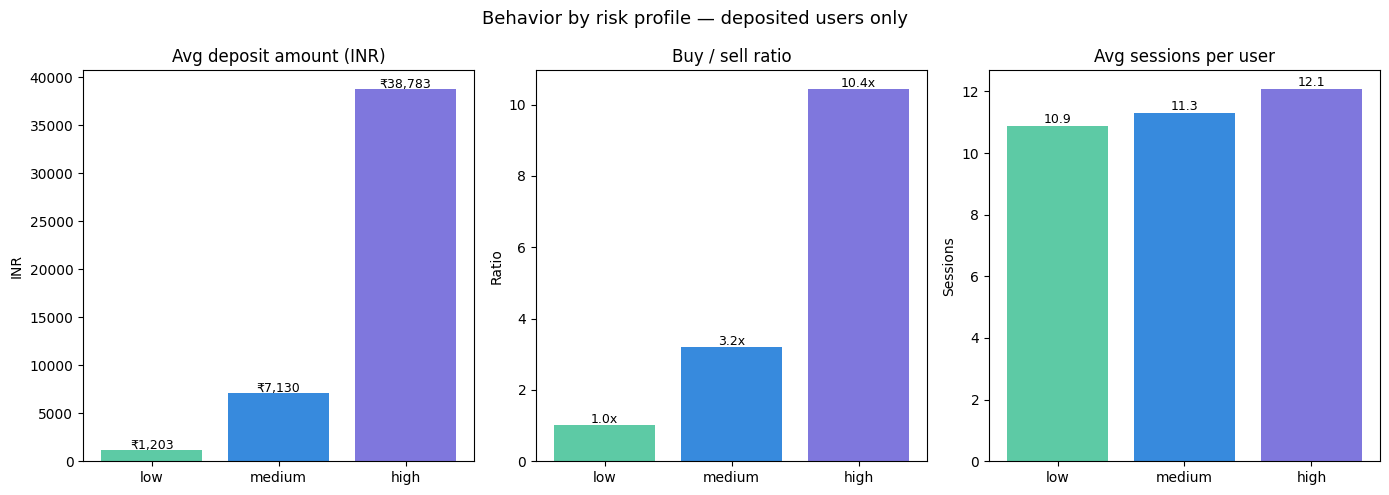

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

colors = ['#5DCAA5', '#378ADD', '#7F77DD']
risk_profiles = df_risk['risk_profile'].tolist()

# Chart 1 — avg deposit amount
axes[0].bar(risk_profiles, df_risk['avg_deposit_amount_inr'], color=colors)
axes[0].set_title('Avg deposit amount (INR)')
axes[0].set_ylabel('INR')
for i, val in enumerate(df_risk['avg_deposit_amount_inr']):
    axes[0].text(i, val + 100, f'₹{int(val):,}', ha='center', fontsize=9)

# Chart 2 — buy/sell ratio
axes[1].bar(risk_profiles, df_risk['buy_sell_ratio'], color=colors)
axes[1].set_title('Buy / sell ratio')
axes[1].set_ylabel('Ratio')
for i, val in enumerate(df_risk['buy_sell_ratio']):
    axes[1].text(i, val + 0.05, f'{val:.1f}x', ha='center', fontsize=9)

# Chart 3 — avg sessions
axes[2].bar(risk_profiles, df_risk['avg_sessions'], color=colors)
axes[2].set_title('Avg sessions per user')
axes[2].set_ylabel('Sessions')
for i, val in enumerate(df_risk['avg_sessions']):
    axes[2].text(i, val + 0.1, f'{val:.1f}', ha='center', fontsize=9)

plt.suptitle('Behavior by risk profile — deposited users only', fontsize=13)
plt.tight_layout()
plt.savefig('risk_behavior.png', dpi=150)
plt.show()

## Risk Profile vs Behavior Analysis

Analyzed 32,926 deposited users segmented by risk profile.

### Key findings

**Deposit behavior**
- High risk users deposit on average ₹38,783 vs ₹1,203 for low risk — a 32x difference
- High risk users also make more deposits per user (2.06 vs 1.81)
- Total deposited: high risk users put in ₹79,774 on average vs ₹2,190 for low risk

**Investment behavior — buy/sell ratio is the strongest signal**
- Low risk:    1.01x — selling almost as much as buying (anxiety-driven)
- Medium risk: 3.20x — measured accumulation
- High risk:  10.44x — almost never sells, pure long-term accumulator
- This confirms high risk users are genuine long-term investors,
  low risk users are reactive and easily spooked

**Feature adoption**
- Auto-invest enabled by 57% of high risk vs 24% of low risk users
  High risk users trust the platform enough to automate investments
- Goals created more by high risk users (0.62 vs 0.43)
  They are more intentional about financial planning

**Engagement**
- High risk users average 12 sessions vs 11 for low risk
  More engaged, more committed to the platform

### Business recommendation
- For low risk users: focus on education and reassurance
  nudge notifications during market dips, not sell prompts
- For high risk users: surface advanced features early
  (tax harvesting, sectoral funds, portfolio analytics)
- Auto-invest is a strong retention signal — push it harder
  during onboarding for all risk profiles

In [14]:
churn_query = """
WITH churn_users AS (
    -- find users who hit at least account_inactive
    SELECT DISTINCT user_id
    FROM events
    WHERE event_type = 'account_inactive'
),
churn_events AS (
    -- get all churn-related events for those users
    SELECT
        e.user_id,
        e.event_type,
        e.timestamp,
        -- LEAD gets the timestamp of the next event for same user
        LEAD(e.event_type)  OVER (PARTITION BY e.user_id ORDER BY e.timestamp) AS next_event,
        LEAD(e.timestamp)   OVER (PARTITION BY e.user_id ORDER BY e.timestamp) AS next_timestamp
    FROM events e
    JOIN churn_users c ON e.user_id = c.user_id
    WHERE e.event_type IN (
        'account_inactive',
        'withdrawal_all_funds',
        'account_closed'
    )
),
churn_sequences AS (
    SELECT
        user_id,
        event_type          AS current_event,
        next_event,
        timestamp           AS current_ts,
        next_timestamp,
        -- days between current and next churn event
        ROUND(EXTRACT(EPOCH FROM (next_timestamp - timestamp)) / 86400, 1) AS days_to_next
    FROM churn_events
    WHERE next_event IS NOT NULL
)
SELECT
    current_event || ' → ' || next_event    AS churn_step,
    COUNT(*)                                AS occurrences,
    ROUND(AVG(days_to_next), 1)             AS avg_days,
    ROUND(MIN(days_to_next), 1)             AS min_days,
    ROUND(MAX(days_to_next), 1)             AS max_days,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP
          (ORDER BY days_to_next)::numeric, 1) AS median_days
FROM churn_sequences
GROUP BY current_event, next_event
ORDER BY current_event
"""

df_churn = pd.read_sql(churn_query, engine)
df_churn

,churn_step,occurrences,avg_days,min_days,max_days,median_days
0,account_inactive → withdrawal_all_funds,1873,7.6,1.0,14.0,7.6
1,withdrawal_all_funds → account_closed,1307,4.0,1.0,7.0,4.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_15300\967092284.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(df_churn['churn_step'], rotation=10, fontsize=8)


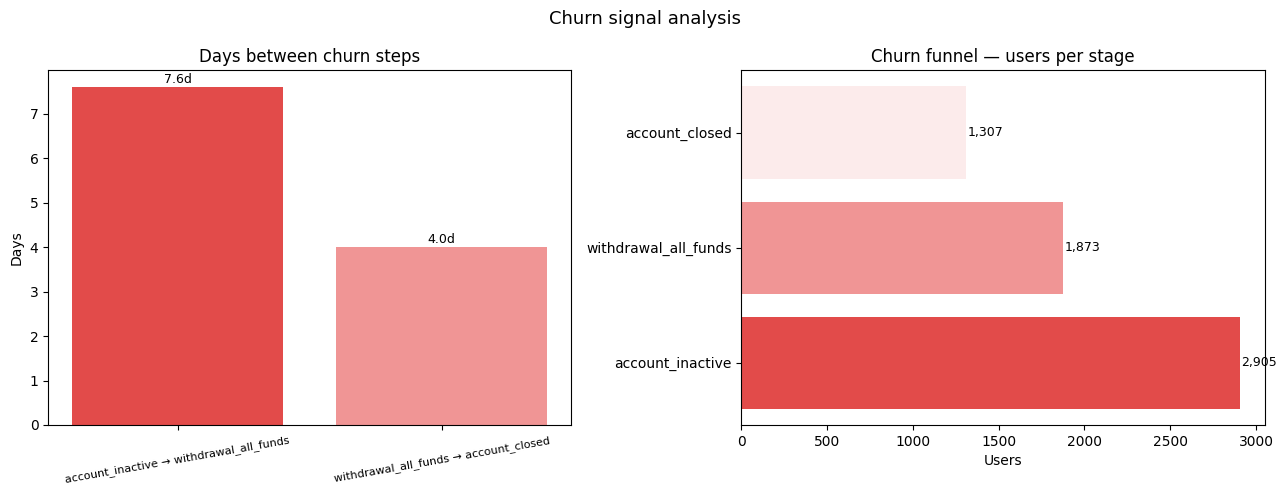

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1 — days between churn steps (median only, clean)
axes[0].bar(df_churn['churn_step'], df_churn['median_days'],
            color=['#E24B4A', '#F09595'])
axes[0].set_title('Days between churn steps')
axes[0].set_ylabel('Days')
axes[0].set_xticklabels(df_churn['churn_step'], rotation=10, fontsize=8)

for i, val in enumerate(df_churn['median_days']):
    axes[0].text(i, val + 0.1, f'{val}d', ha='center', fontsize=9)

# Chart 2 — churn funnel
df_churn_funnel = pd.read_sql("""
    SELECT event_type, COUNT(DISTINCT user_id) as users
    FROM events
    WHERE event_type IN (
        'account_inactive', 'withdrawal_all_funds', 'account_closed'
    )
    GROUP BY event_type
    ORDER BY users DESC
""", engine)

axes[1].barh(df_churn_funnel['event_type'],
             df_churn_funnel['users'],
             color=['#E24B4A', '#F09595', '#FCEBEB'])
axes[1].set_title('Churn funnel — users per stage')
axes[1].set_xlabel('Users')

for i, val in enumerate(df_churn_funnel['users']):
    axes[1].text(val + 10, i, f'{val:,}', va='center', fontsize=9)

plt.suptitle('Churn signal analysis', fontsize=13)
plt.tight_layout()
plt.savefig('churn_signals.png', dpi=150)
plt.show()

In [16]:
churn_query = """
WITH churned_users AS (
    SELECT
        u.user_id,
        u.risk_profile,
        u.first_deposit_at,

        -- did they withdraw everything?
        MAX(CASE WHEN e.event_type = 'withdrawal_all_funds'
            THEN 1 ELSE 0 END)                          AS did_withdraw_all,

        -- did they close account?
        MAX(CASE WHEN e.event_type = 'account_closed'
            THEN 1 ELSE 0 END)                          AS did_close,

        -- did they close portfolio?
        MAX(CASE WHEN e.event_type = 'portfolio_closed'
            THEN 1 ELSE 0 END)                          AS did_close_portfolio,

        -- total deposited
        SUM(CASE WHEN e.event_type = 'deposit_completed'
            THEN (e.properties->>'amount')::numeric
            ELSE 0 END)                                 AS total_deposited,

        -- total withdrawn
        SUM(CASE WHEN e.event_type = 'withdrawal_completed'
            THEN (e.properties->>'amount')::numeric
            ELSE 0 END)                                 AS total_withdrawn,

        -- last activity
        MAX(e.timestamp)                                AS last_event_date,
        COUNT(DISTINCT e.session_id)                    AS total_sessions

    FROM users u
    JOIN events e ON u.user_id = e.user_id
    WHERE u.first_deposit_at IS NOT NULL
    GROUP BY u.user_id, u.risk_profile, u.first_deposit_at
)
SELECT
    risk_profile,

    COUNT(*)                                            AS total_activated_users,

    -- hard churn: withdrew all money AND closed account
    SUM(CASE WHEN did_withdraw_all = 1
             AND did_close = 1
             THEN 1 ELSE 0 END)                         AS hard_churned,

    -- soft churn: withdrew all but didn't close
    SUM(CASE WHEN did_withdraw_all = 1
             AND did_close = 0
             THEN 1 ELSE 0 END)                         AS soft_churned,

    -- portfolio closed but account open
    SUM(CASE WHEN did_close_portfolio = 1
             AND did_close = 0
             THEN 1 ELSE 0 END)                         AS portfolio_closed_only,

    -- healthy: still have money, never withdrew all
    SUM(CASE WHEN did_withdraw_all = 0
             AND did_close = 0
             THEN 1 ELSE 0 END)                         AS healthy_users,

    -- rates
    ROUND(SUM(CASE WHEN did_withdraw_all = 1
                   AND did_close = 1
                   THEN 1 ELSE 0 END) * 100.0
          / COUNT(*), 1)                                AS hard_churn_pct,

    ROUND(SUM(CASE WHEN did_withdraw_all = 0
                   AND did_close = 0
                   THEN 1 ELSE 0 END) * 100.0
          / COUNT(*), 1)                                AS healthy_pct

FROM churned_users
GROUP BY risk_profile
ORDER BY CASE risk_profile
    WHEN 'low' THEN 1
    WHEN 'medium' THEN 2
    WHEN 'high' THEN 3
END
"""

df_churn = pd.read_sql(churn_query, engine)
df_churn
# hard_churned     = withdrew ALL money + closed account
#                    → definitively gone

# soft_churned     = withdrew all money but kept account
#                    → money gone but door still open

# portfolio_closed = closed portfolio but kept account
#                    → paused, not gone

# healthy          = money still there, account open
#                    → normal user, may or may not be logging in

,risk_profile,total_activated_users,hard_churned,soft_churned,portfolio_closed_only,healthy_users,hard_churn_pct,healthy_pct
0,low,10937,709,315,336,9913,6.5,90.6
1,medium,13843,496,202,496,13145,3.6,95.0
2,high,7146,102,49,279,6995,1.4,97.9


## Churn Analysis

**Important note on definition:**
Churn is defined by ACTION not inactivity.
A user with invested money who hasn't logged in for months
is NOT churned — their money is working. True churn means:

- Hard churn  = withdrew ALL funds + closed account (gone for good)
- Soft churn  = withdrew all funds but kept account (money gone, door open)
- Portfolio closed = closed portfolio but kept account (paused)
- Healthy     = money still invested, account open (normal customer)

### Results by risk profile

| Risk | Activated | Hard churn % | Healthy % |
|------|-----------|--------------|-----------|
| Low    | 10,937  | 6.5%         | 90.6%     |
| Medium | 13,843  | 3.6%         | 95.0%     |
| High   |  7,146  | 1.4%         | 97.9%     |

### Key insights

**High risk users are the most loyal customers**
Only 1.4% hard churn rate vs 6.5% for low risk.
High risk users are long-term wealth builders —
they deposit more, invest more, and almost never leave.

**Low risk users need the most attention**
6.5% hard churn — nearly 5x higher than high risk.
These users are anxiety-driven. Market dips, poor UX,
or lack of reassurance pushes them to withdraw and close.

**Soft churn is a recovery opportunity**
These users pulled their money but kept their account open.
A targeted campaign (market recovery update, zero-fee offer)
could bring their deposits back.

### Business recommendation
Segment your retention strategy by risk profile:
- High risk   → leave them alone, they're your best users
- Medium risk → periodic portfolio performance updates
- Low risk    → proactive reassurance during market volatility,
                educational content, guided support

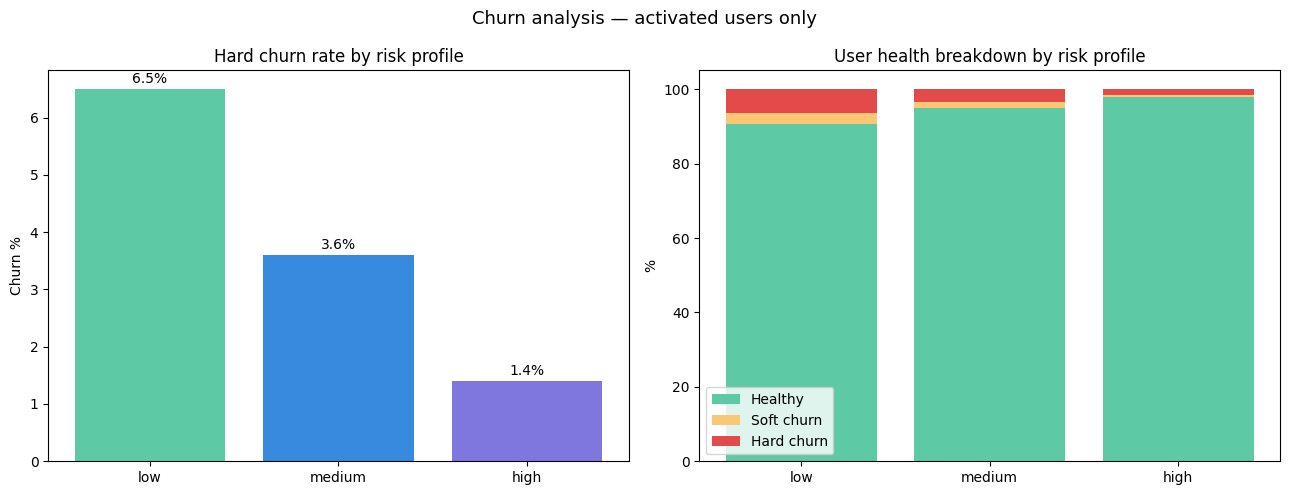

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#5DCAA5', '#378ADD', '#7F77DD']
risk_profiles = df_churn['risk_profile'].tolist()

# Chart 1 — hard churn % by risk profile
axes[0].bar(risk_profiles, df_churn['hard_churn_pct'], color=colors)
axes[0].set_title('Hard churn rate by risk profile')
axes[0].set_ylabel('Churn %')
for i, val in enumerate(df_churn['hard_churn_pct']):
    axes[0].text(i, val + 0.1, f'{val}%', ha='center', fontsize=10)

# Chart 2 — stacked bar: healthy vs soft churn vs hard churn
hard   = df_churn['hard_churn_pct']
soft   = (df_churn['soft_churned'] * 100 / df_churn['total_activated_users']).round(1)
healthy = df_churn['healthy_pct']

axes[1].bar(risk_profiles, healthy, label='Healthy',         color='#5DCAA5')
axes[1].bar(risk_profiles, soft,    label='Soft churn',      color='#FAC775',
            bottom=healthy)
axes[1].bar(risk_profiles, hard,    label='Hard churn',      color='#E24B4A',
            bottom=healthy + soft)

axes[1].set_title('User health breakdown by risk profile')
axes[1].set_ylabel('%')
axes[1].legend()

plt.suptitle('Churn analysis — activated users only', fontsize=13)
plt.tight_layout()
plt.savefig('churn_analysis.png', dpi=150)
plt.show()

In [30]:
session_query = """
WITH session_stats AS (
    SELECT
        e.session_id,
        e.user_id,
        u.risk_profile,
        u.device_type,
        COUNT(e.event_id)            AS events_in_session,
        COUNT(DISTINCT e.event_type) AS unique_actions
    FROM events e
    JOIN users u ON e.user_id = u.user_id
    WHERE u.first_deposit_at IS NOT NULL
    AND e.event_type NOT IN ('login', 'logout')
    GROUP BY e.session_id, e.user_id, u.risk_profile, u.device_type
    HAVING COUNT(e.event_id) > 1
),
bucketed AS (
    SELECT
        risk_profile,
        device_type,
        CASE
            WHEN events_in_session <= 3  THEN '1. light (1-3 events)'
            WHEN events_in_session <= 6  THEN '2. medium (4-6 events)'
            WHEN events_in_session <= 9  THEN '3. deep (7-9 events)'
            ELSE                              '4. power (10+ events)'
        END AS session_type,
        events_in_session,
        unique_actions
    FROM session_stats
)
SELECT
    session_type,
    risk_profile,
    COUNT(*)                         AS total_sessions,
    ROUND(AVG(events_in_session), 1) AS avg_events,
    ROUND(AVG(unique_actions), 1)    AS avg_unique_actions,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER 
          (PARTITION BY risk_profile), 1) AS pct_of_user_sessions
FROM bucketed
GROUP BY session_type, risk_profile
ORDER BY session_type, risk_profile
"""

df_session = pd.read_sql(session_query, engine)
df_session

,session_type,risk_profile,total_sessions,avg_events,avg_unique_actions,pct_of_user_sessions
0,1. light (1-3 events),high,27775,2.9,2.9,35.4
1,1. light (1-3 events),low,41831,2.8,2.8,39.4
2,1. light (1-3 events),medium,53421,2.9,2.9,37.9
3,2. medium (4-6 events),high,39129,4.7,4.7,49.9
4,2. medium (4-6 events),low,49587,4.6,4.6,46.7
5,2. medium (4-6 events),medium,67511,4.7,4.7,47.9
6,3. deep (7-9 events),high,4275,7.4,7.4,5.4
7,3. deep (7-9 events),low,3756,7.4,7.3,3.5
8,3. deep (7-9 events),medium,5905,7.4,7.4,4.2
9,4. power (10+ events),high,7286,11.2,4.3,9.3


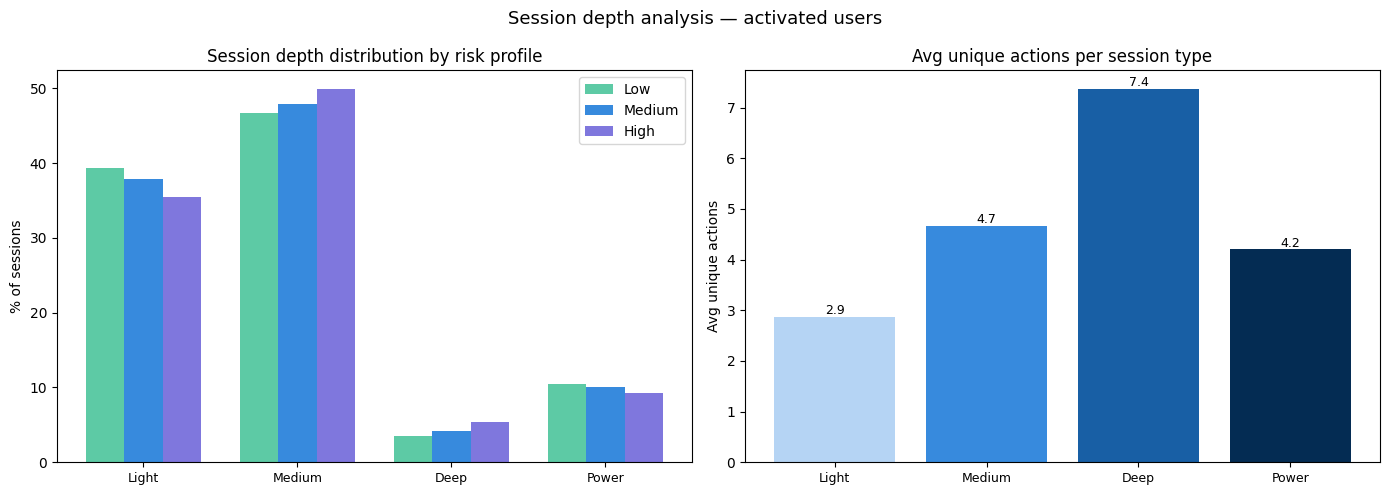

In [31]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — session distribution by risk profile (stacked %)
session_types = ['1. light (1-3 events)', '2. medium (4-6 events)',
                 '3. deep (7-9 events)',  '4. power (10+ events)']
colors_session = ['#B5D4F4', '#378ADD', '#185FA5', '#042C53']

for risk, ax_offset, color_base in [('low', -0.25, 0),
                                     ('medium', 0, 1),
                                     ('high', 0.25, 2)]:
    df_r = df_session[df_session['risk_profile'] == risk].set_index('session_type')
    vals = [df_r.loc[st, 'pct_of_user_sessions']
            if st in df_r.index else 0 for st in session_types]
    x = np.arange(len(session_types))
    axes[0].bar(x + ax_offset, vals, width=0.25,
                label=risk.capitalize(),
                color=['#5DCAA5', '#378ADD', '#7F77DD'][color_base])

axes[0].set_xticks(np.arange(len(session_types)))
axes[0].set_xticklabels(['Light', 'Medium', 'Deep', 'Power'], fontsize=9)
axes[0].set_ylabel('% of sessions')
axes[0].set_title('Session depth distribution by risk profile')
axes[0].legend()

# Chart 2 — avg unique actions by session type
df_actions = df_session.groupby('session_type')['avg_unique_actions'].mean()
axes[1].bar(range(len(df_actions)),
            df_actions.values,
            color=['#B5D4F4', '#378ADD', '#185FA5', '#042C53'])
axes[1].set_xticks(range(len(df_actions)))
axes[1].set_xticklabels(['Light', 'Medium', 'Deep', 'Power'], fontsize=9)
axes[1].set_ylabel('Avg unique actions')
axes[1].set_title('Avg unique actions per session type')

for i, val in enumerate(df_actions.values):
    axes[1].text(i, val + 0.05, f'{val:.1f}', ha='center', fontsize=9)

plt.suptitle('Session depth analysis — activated users', fontsize=13)
plt.tight_layout()
plt.savefig('session_depth.png', dpi=150)
plt.show()

## Session Depth Analysis

Analyzed session behavior of 32,926 activated users,
excluding login/logout events and single-event sessions.

### Session type distribution

| Session type | Low risk | Medium risk | High risk |
|---|---|---|---|
| Light (1-3 events)  | 39.4% | 37.9% | 35.4% |
| Medium (4-6 events) | 46.7% | 47.9% | 49.9% |
| Deep (7-9 events)   |  3.5% |  4.2% |  5.4% |
| Power (10+ events)  | 10.4% | 10.0% |  9.3% |

### Key insights

**Medium sessions dominate across all risk profiles (~47-50%)**
Most users do a focused set of actions per session —
view dashboard, check portfolio, maybe make one investment.
This is healthy, intentional usage.

**High risk users have more deep sessions (5.4% vs 3.5%)**
High risk users are more exploratory — they check more
features, view more charts, and take more actions per session.

**Power sessions are consistent across all profiles (~10%)**
About 1 in 10 sessions is a power session regardless of
risk profile — these are likely triggered by market events
or SIP dates when users come in with specific intent.

**Light sessions are higher for low risk users (39.4% vs 35.4%)**
Low risk users open the app, check quickly, and leave.
Less exploration, more anxiety-checking behavior.

### Note on session duration
Session duration was excluded from this analysis because
the simulator's intra-session event gaps make duration
an unreliable metric. Event count and unique actions
are the honest measures from simulated data.
